In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


In [20]:
df = pd.read_csv("C:/Users/ASUS/student_name_data_cleaning/data/hotel_bookings.csv")
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nFirst 5 Rows:\n", df.head())
print("\nLast 5 Rows:\n", df.tail())
print("\nDescribe:\n", df.describe(include='all'))



Shape: (119390, 32)

Data Types:
 hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object


          Missing    Percent
children        4   0.003350
country       488   0.408744
agent       16340  13.686238
company    112593  94.306893


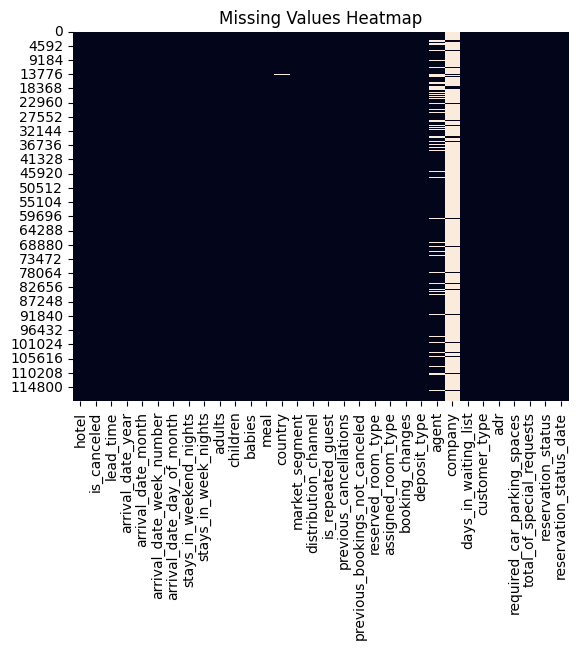

In [21]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_report = pd.DataFrame({'Missing': missing, 'Percent': missing_percent})
print(missing_report[missing_report['Missing'] > 0])

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()


In [22]:
# Duplicates
print("Duplicates:", df.duplicated().sum())

# Categorical check
print(df['meal'].value_counts())

# Logical errors
df[df['adults'] + df['children'] + df['babies'] == 0]


Duplicates: 31994
meal
BB           92310
HB           14463
SC           10650
Undefined     1169
FB             798
Name: count, dtype: int64


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,NaN,174.0,0,Transient-Party,0.00,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,NaN,174.0,0,Transient,0.00,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38.0,NaN,0,Transient-Party,0.00,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.00,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308.0,NaN,122,Transient-Party,0.00,0,0,Check-Out,2016-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115029,City Hotel,0,107,2017,June,26,27,0,3,0,...,No Deposit,7.0,NaN,0,Transient,100.80,0,0,Check-Out,2017-06-30
115091,City Hotel,0,1,2017,June,26,30,0,1,0,...,No Deposit,NaN,NaN,0,Transient,0.00,1,1,Check-Out,2017-07-01
116251,City Hotel,0,44,2017,July,28,15,1,1,0,...,No Deposit,425.0,NaN,0,Transient,73.80,0,0,Check-Out,2017-07-17
116534,City Hotel,0,2,2017,July,28,15,2,5,0,...,No Deposit,9.0,NaN,0,Transient-Party,22.86,0,1,Check-Out,2017-07-22


In [23]:
df['children'].fillna(0, inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)
df['country'].fillna('Unknown', inplace=True)


In [24]:
print("Before:", df.shape)
df.drop_duplicates(inplace=True)
print("After:", df.shape)


Before: (119390, 32)
After: (87396, 32)


In [25]:
num_cols = ['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
            'adults', 'children', 'babies', 'adr']

# IQR Method
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]


In [27]:
# Fix 0 total guests
df = df[~((df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0))]

# Fix date
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

# Standardize meal
df['meal'].replace('Undefined', 'SC', inplace=True)


In [28]:
# Check guests
assert (df['adults'] + df['children'] + df['babies']).min() > 0

# Check arrival year range
print(df['arrival_date_year'].value_counts())

# Validate values
print(df['deposit_type'].unique())


arrival_date_year
2016    24938
2017    18054
2015     8233
Name: count, dtype: int64
['No Deposit' 'Non Refund' 'Refundable']


In [31]:
df.to_csv('C:/Users/ASUS/student_name_data_cleaning/data/hotel_bookings_cleaned.csv', index=False)


In [35]:
import sys
sys.path.append('../scripts')

from cleaning_functions import clean_hotel_data
import pandas as pd
import os

# Load original dataset
df = pd.read_csv('C:/Users/ASUS/student_name_data_cleaning/data/hotel_bookings.csv')

# Run the full cleaning pipeline
cleaned_df = clean_hotel_data(df)

# Ensure the 'data' directory exists before saving
os.makedirs('data', exist_ok=True)

# Save cleaned dataset
cleaned_df.to_csv('data/hotel_bookings_cleaned.csv', index=False)
